# Fase 1 - Analisis Exploratorio Del Dataset De Radiografias

Este notebook documenta la primera fase del proyecto: importar el dataset, validar las anotaciones YOLO, visualizar radiografias con bounding boxes y extraer decisiones para el preprocesado futuro.

**Objetivo del proyecto:** construir una herramienta accesible para que personal medico pueda ocultar informacion sensible en radiografias antes de compartirlas o reutilizarlas.

**Importante:** este notebook no modifica el dataset original. Solo lee imagenes y etiquetas para analizarlas.

## 1. Importacion y configuracion

El dataset sigue una estructura compatible con YOLO: imagenes separadas en `train` y `val`, y etiquetas `.txt` con coordenadas normalizadas.

In [1]:
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13

NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = Path("../hackathon_TREE_AIBiomed 2")
if not DATASET_DIR.exists():
    DATASET_DIR = Path("hackathon_TREE_AIBiomed 2")

assert DATASET_DIR.exists(), f"No se encontro el dataset en {DATASET_DIR.resolve()}"
DATA_YAML = DATASET_DIR / "data.yaml"
assert DATA_YAML.exists(), f"No se encontro data.yaml en {DATA_YAML.resolve()}"

raw_yaml = DATA_YAML.read_text(encoding="utf-8").strip()
if raw_yaml.startswith("```"):
    raw_yaml = "\n".join(raw_yaml.splitlines()[1:])
if raw_yaml.endswith("```"):
    raw_yaml = "\n".join(raw_yaml.splitlines()[:-1])
data_config = yaml.safe_load(raw_yaml)

class_names = {int(k): v for k, v in data_config["names"].items()}
splits = ["train", "val"]

print(f"Dataset: {DATASET_DIR.resolve()}")
print(f"Clases ({len(class_names)}): {class_names}")

Dataset: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/hackathon_TREE_AIBiomed 2
Clases (5): {0: 'name', 1: 'id', 2: 'age', 3: 'date', 4: 'time'}


## 2. Lectura de imagenes y anotaciones

Hay un detalle relevante en este dataset: las imagenes terminan en `_annotated.png`, mientras que las etiquetas usan el mismo identificador sin ese sufijo. El notebook lo contempla al emparejar cada imagen con su archivo `.txt`.

In [2]:
def image_base_id(image_path: Path) -> str:
    """Devuelve el identificador usado por las etiquetas YOLO."""
    stem = image_path.stem
    suffix = "_annotated"
    return stem[:-len(suffix)] if stem.endswith(suffix) else stem


def label_path_for_image(image_path: Path, split: str) -> Path:
    return DATASET_DIR / "labels" / split / f"{image_base_id(image_path)}.txt"


def read_yolo_label(label_path):
    boxes = []
    if not label_path.exists():
        return boxes
    for row_number, raw_line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Etiqueta invalida en {label_path}, linea {row_number}: {raw_line}")
        class_id = int(parts[0])
        x_center, y_center, box_width, box_height = map(float, parts[1:])
        boxes.append({
            "class_id": class_id,
            "class_name": class_names.get(class_id, f"class_{class_id}"),
            "x_center": x_center,
            "y_center": y_center,
            "box_width": box_width,
            "box_height": box_height,
        })
    return boxes


image_rows = []
box_rows = []

for split in splits:
    image_dir = DATASET_DIR / "images" / split
    for image_path in sorted(image_dir.glob("*.png")):
        label_path = label_path_for_image(image_path, split)
        with Image.open(image_path) as img:
            width, height = img.size
            gray = np.asarray(img.convert("L"))

        labels = read_yolo_label(label_path)
        image_rows.append({
            "split": split,
            "image_id": image_base_id(image_path),
            "image_name": image_path.name,
            "image_path": image_path,
            "label_path": label_path,
            "label_exists": label_path.exists(),
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "mean_intensity": float(gray.mean()),
            "std_intensity": float(gray.std()),
            "min_intensity": int(gray.min()),
            "max_intensity": int(gray.max()),
            "n_boxes": len(labels),
        })

        for box in labels:
            x_center_abs = box["x_center"] * width
            y_center_abs = box["y_center"] * height
            box_width_abs = box["box_width"] * width
            box_height_abs = box["box_height"] * height
            box_rows.append({
                "split": split,
                "image_id": image_base_id(image_path),
                "image_name": image_path.name,
                "image_path": image_path,
                "label_path": label_path,
                **box,
                "area_relative": box["box_width"] * box["box_height"],
                "x_min": x_center_abs - box_width_abs / 2,
                "y_min": y_center_abs - box_height_abs / 2,
                "x_max": x_center_abs + box_width_abs / 2,
                "y_max": y_center_abs + box_height_abs / 2,
                "box_width_px": box_width_abs,
                "box_height_px": box_height_abs,
            })

images_df = pd.DataFrame(image_rows)
boxes_df = pd.DataFrame(box_rows)

display(images_df.head())
display(boxes_df.head())

,split,image_id,image_name,image_path,label_path,label_exists,width,height,aspect_ratio,mean_intensity,std_intensity,min_intensity,max_intensity,n_boxes
0,train,051b7911-cb00aec9-0b309188-89803662-303ec278,051b7911-cb00aec9-0b309188-89803662-303ec278_a...,../hackathon_TREE_AIBiomed 2/images/train/051b...,../hackathon_TREE_AIBiomed 2/labels/train/051b...,True,512,512,1.0,118.203705,79.291201,0,255,4
1,train,0580e01f-2d3d20e1-50889949-d6d14236-0bc532e3,0580e01f-2d3d20e1-50889949-d6d14236-0bc532e3_a...,../hackathon_TREE_AIBiomed 2/images/train/0580...,../hackathon_TREE_AIBiomed 2/labels/train/0580...,True,512,512,1.0,92.394894,84.920764,0,255,4
2,train,060b1fcc-5f90c680-8ce2e1f5-40d3ac27-2dced2d6,060b1fcc-5f90c680-8ce2e1f5-40d3ac27-2dced2d6_a...,../hackathon_TREE_AIBiomed 2/images/train/060b...,../hackathon_TREE_AIBiomed 2/labels/train/060b...,True,512,512,1.0,95.654385,85.035526,0,255,5
3,train,06e3e705-7d20dcc5-21be668e-587b1be1-158ba455,06e3e705-7d20dcc5-21be668e-587b1be1-158ba455_a...,../hackathon_TREE_AIBiomed 2/images/train/06e3...,../hackathon_TREE_AIBiomed 2/labels/train/06e3...,True,512,512,1.0,108.596760,82.570712,0,255,4
4,train,074987b9-26c19a32-5d80ebab-28a2fb1c-6191b91f,074987b9-26c19a32-5d80ebab-28a2fb1c-6191b91f_a...,../hackathon_TREE_AIBiomed 2/images/train/0749...,../hackathon_TREE_AIBiomed 2/labels/train/0749...,True,512,512,1.0,128.801041,73.720281,0,255,4


,split,image_id,image_name,image_path,label_path,class_id,class_name,x_center,y_center,box_width,box_height,area_relative,x_min,y_min,x_max,y_max,box_width_px,box_height_px
0,train,051b7911-cb00aec9-0b309188-89803662-303ec278,051b7911-cb00aec9-0b309188-89803662-303ec278_a...,../hackathon_TREE_AIBiomed 2/images/train/051b...,../hackathon_TREE_AIBiomed 2/labels/train/051b...,0,name,0.205078,0.051758,0.238281,0.017578,0.004189,44.000000,22.000128,165.999872,31.000064,121.999872,8.999936
1,train,051b7911-cb00aec9-0b309188-89803662-303ec278,051b7911-cb00aec9-0b309188-89803662-303ec278_a...,../hackathon_TREE_AIBiomed 2/images/train/051b...,../hackathon_TREE_AIBiomed 2/labels/train/051b...,1,id,0.117188,0.073242,0.082031,0.017578,0.001442,39.000320,32.999936,81.000192,41.999872,41.999872,8.999936
2,train,051b7911-cb00aec9-0b309188-89803662-303ec278,051b7911-cb00aec9-0b309188-89803662-303ec278_a...,../hackathon_TREE_AIBiomed 2/images/train/051b...,../hackathon_TREE_AIBiomed 2/labels/train/051b...,2,age,0.222656,0.073242,0.050781,0.017578,0.000893,100.999936,32.999936,126.999808,41.999872,25.999872,8.999936
3,train,051b7911-cb00aec9-0b309188-89803662-303ec278,051b7911-cb00aec9-0b309188-89803662-303ec278_a...,../hackathon_TREE_AIBiomed 2/images/train/051b...,../hackathon_TREE_AIBiomed 2/labels/train/051b...,3,date,0.112305,0.094727,0.150391,0.017578,0.002644,19.000064,44.000256,96.000256,53.000192,77.000192,8.999936
4,train,0580e01f-2d3d20e1-50889949-d6d14236-0bc532e3,0580e01f-2d3d20e1-50889949-d6d14236-0bc532e3_a...,../hackathon_TREE_AIBiomed 2/images/train/0580...,../hackathon_TREE_AIBiomed 2/labels/train/0580...,0,name,0.619141,0.053711,0.199219,0.017578,0.003502,266.000128,23.000064,368.000256,32.000000,102.000128,8.999936


## 3. Validacion del dataset

Antes de entrenar cualquier modelo conviene confirmar que las anotaciones se pueden leer, que no hay cajas fuera de rango y que cada imagen tiene su etiqueta.

In [3]:
summary = {
    "imagenes_total": len(images_df),
    "etiquetas_existentes": int(images_df["label_exists"].sum()),
    "boxes_total": len(boxes_df),
    "imagenes_sin_label": int((~images_df["label_exists"]).sum()),
    "imagenes_sin_boxes": int((images_df["n_boxes"] == 0).sum()),
}

range_checks = {
    "x_center_out_of_range": int(((boxes_df["x_center"] < 0) | (boxes_df["x_center"] > 1)).sum()),
    "y_center_out_of_range": int(((boxes_df["y_center"] < 0) | (boxes_df["y_center"] > 1)).sum()),
    "box_width_out_of_range": int(((boxes_df["box_width"] <= 0) | (boxes_df["box_width"] > 1)).sum()),
    "box_height_out_of_range": int(((boxes_df["box_height"] <= 0) | (boxes_df["box_height"] > 1)).sum()),
}

print("Resumen de validacion")
for key, value in summary.items():
    print(f"- {key}: {value}")

print("\nCoordenadas YOLO fuera de rango")
for key, value in range_checks.items():
    print(f"- {key}: {value}")

assert summary["imagenes_total"] == 400, "El numero de imagenes no coincide con lo esperado"
assert summary["etiquetas_existentes"] == 400, "Hay imagenes sin etiqueta emparejada"
assert summary["boxes_total"] == 1733, "El numero de cajas no coincide con lo esperado"
assert sum(range_checks.values()) == 0, "Hay coordenadas YOLO fuera de rango"

Resumen de validacion
- imagenes_total: 400
- etiquetas_existentes: 400
- boxes_total: 1733
- imagenes_sin_label: 0
- imagenes_sin_boxes: 0

Coordenadas YOLO fuera de rango
- x_center_out_of_range: 0
- y_center_out_of_range: 0
- box_width_out_of_range: 0
- box_height_out_of_range: 0


In [4]:
split_summary = images_df.groupby("split").agg(
    n_images=("image_id", "count"),
    n_boxes=("n_boxes", "sum"),
    mean_boxes=("n_boxes", "mean"),
    mean_intensity=("mean_intensity", "mean"),
    mean_std_intensity=("std_intensity", "mean"),
).round(2)

size_summary = images_df.groupby(["split", "width", "height"]).size().reset_index(name="n_images")

display(split_summary)
display(size_summary)

print("Hallazgo importante:")
print("- 399 imagenes son de 512x512.")
print("- 1 imagen de train es de 2170x3056, por lo que conviene normalizar tamanos en el pipeline de entrenamiento.")

,n_images,n_boxes,mean_boxes,mean_intensity,mean_std_intensity
split,,,,,
train,320,1389,4.34,121.1,76.86
val,80,344,4.30,120.4,77.19


,split,width,height,n_images
0,train,512,512,319
1,train,2170,3056,1
2,val,512,512,80


Hallazgo importante:
- 399 imagenes son de 512x512.
- 1 imagen de train es de 2170x3056, por lo que conviene normalizar tamanos en el pipeline de entrenamiento.


## 4. Visualizacion de radiografias con bounding boxes

La funcion siguiente convierte las coordenadas YOLO normalizadas a coordenadas absolutas y dibuja cada caja sobre la radiografia. Esto permite revisar visualmente si las anotaciones cubren correctamente los campos sensibles.

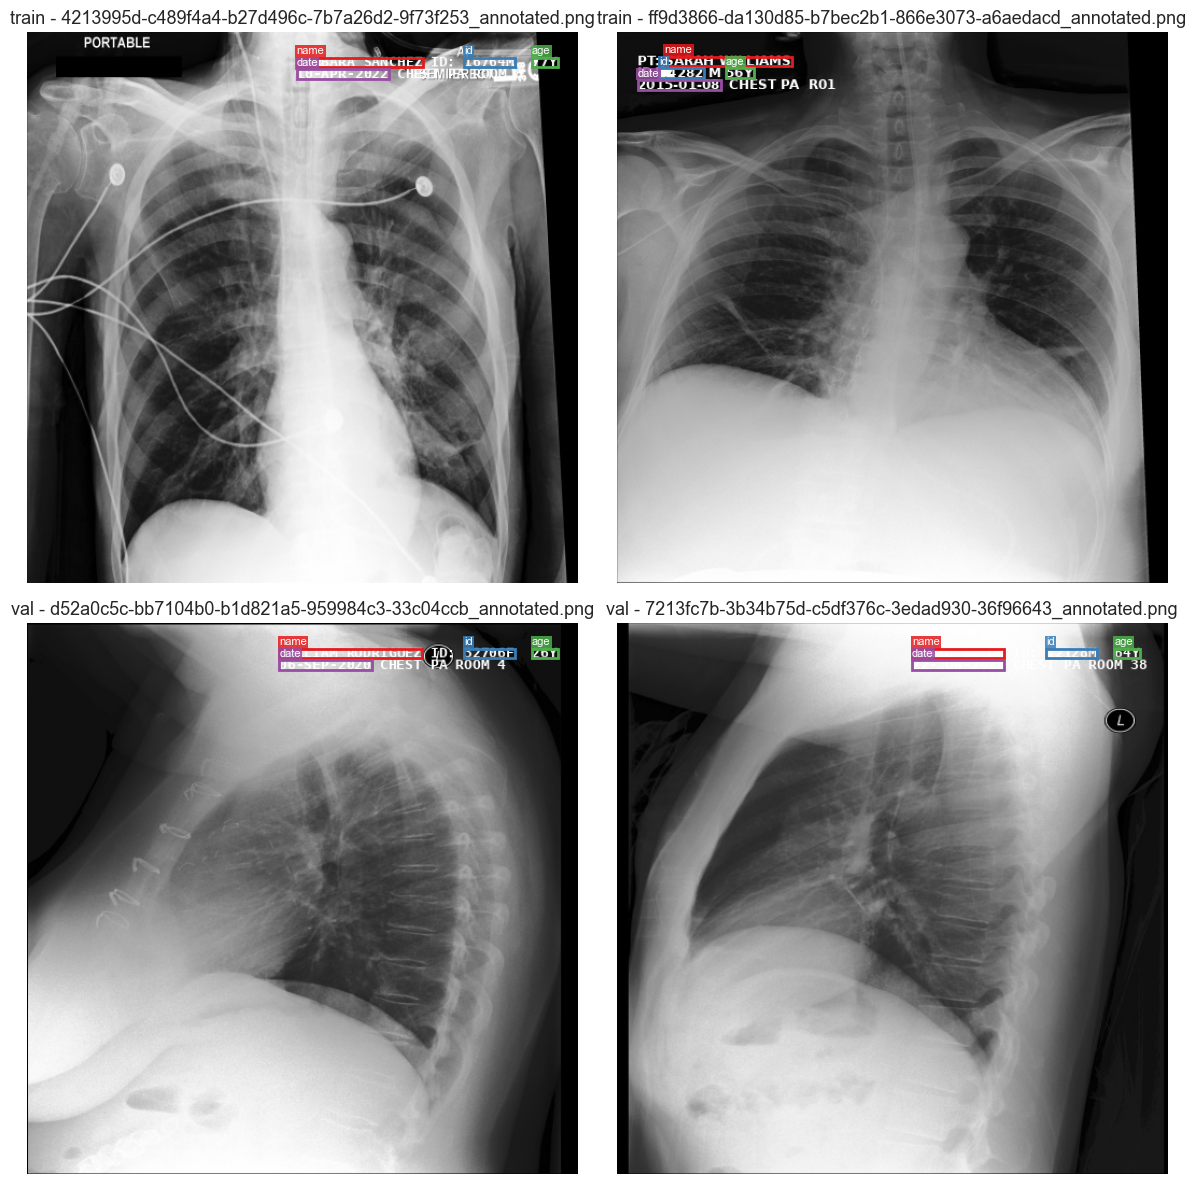

In [5]:
CLASS_COLORS = {
    "name": "#e41a1c",
    "id": "#377eb8",
    "age": "#4daf4a",
    "date": "#984ea3",
    "time": "#ff7f00",
}


def plot_image_with_boxes(image_row, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    image_path = image_row["image_path"]
    image_boxes = boxes_df[boxes_df["image_id"] == image_row["image_id"]]
    img = Image.open(image_path).convert("RGB")

    ax.imshow(img, cmap="gray")
    ax.axis("off")

    for _, box in image_boxes.iterrows():
        color = CLASS_COLORS.get(box["class_name"], "yellow")
        rect = patches.Rectangle(
            (box["x_min"], box["y_min"]),
            box["box_width_px"],
            box["box_height_px"],
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            box["x_min"],
            max(0, box["y_min"] - 3),
            box["class_name"],
            color="white",
            fontsize=8,
            bbox={"facecolor": color, "alpha": 0.85, "pad": 1, "edgecolor": "none"},
        )

    ax.set_title(title or image_path.name)
    return ax


sample_images = pd.concat([
    images_df[images_df["split"] == "train"].sample(2, random_state=7),
    images_df[images_df["split"] == "val"].sample(2, random_state=7),
])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (_, row) in zip(axes.flat, sample_images.iterrows()):
    plot_image_with_boxes(row, ax=ax, title=f"{row['split']} - {row['image_name']}")
plt.tight_layout()
plt.show()

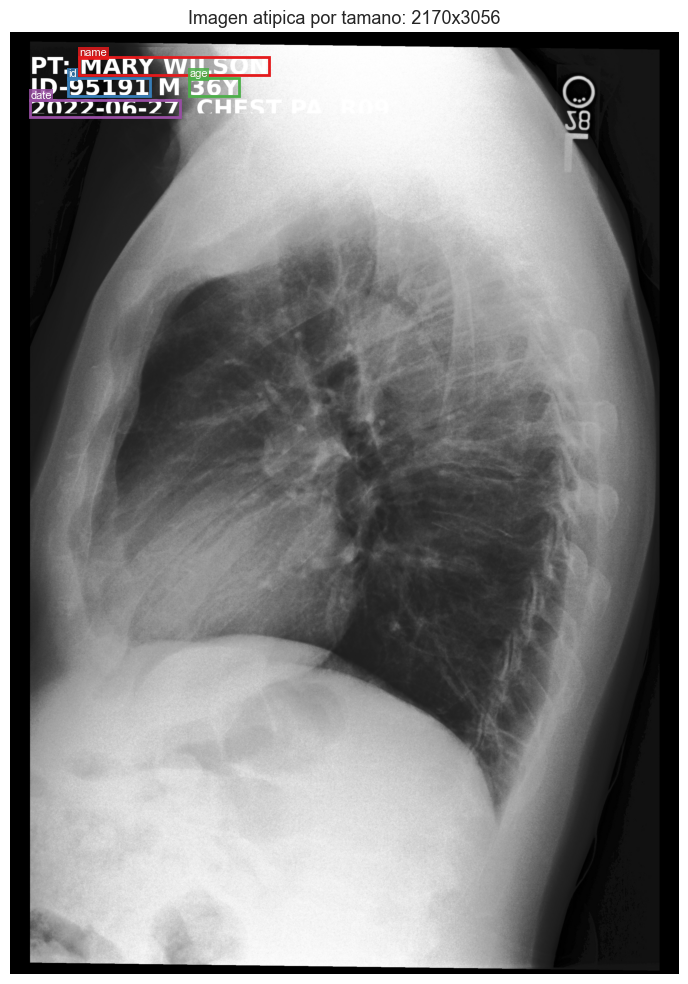

In [6]:
large_images = images_df[(images_df["width"] != 512) | (images_df["height"] != 512)]
if not large_images.empty:
    row = large_images.iloc[0]
    fig, ax = plt.subplots(figsize=(8, 10))
    plot_image_with_boxes(row, ax=ax, title=f"Imagen atipica por tamano: {row['width']}x{row['height']}")
    plt.tight_layout()
    plt.show()
else:
    print("No hay imagenes con tamano distinto al formato principal.")

## 5. Distribuciones principales

Estas graficas ayudan a decidir si el dataset esta balanceado, donde aparecen las zonas sensibles y que transformaciones pueden ser utiles para entrenar un detector robusto.

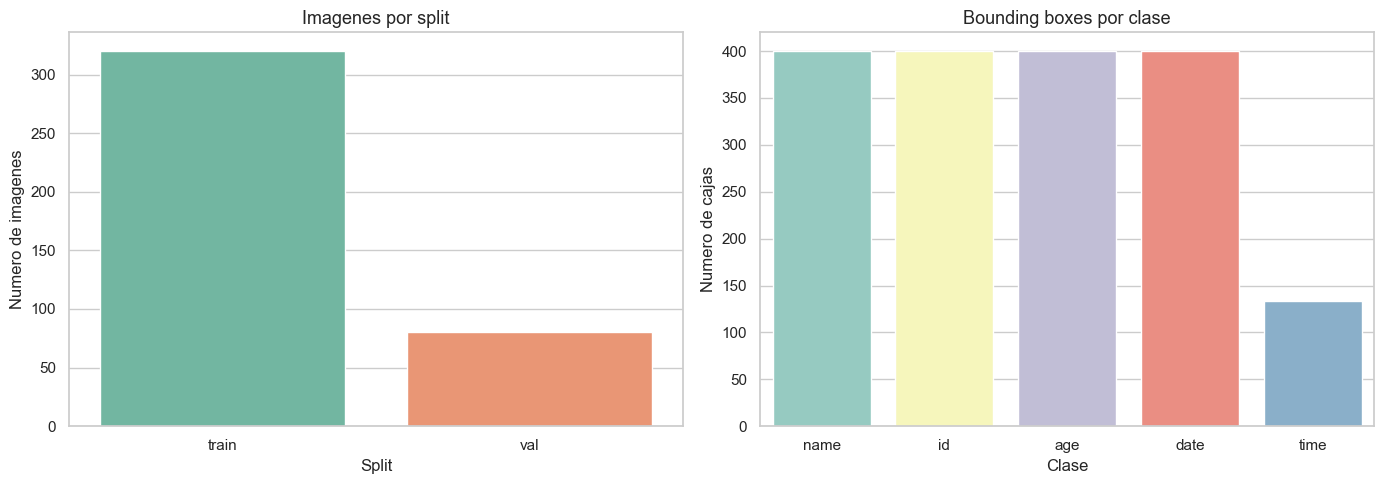

class_name,name,id,age,date,time
split,,,,,
train,320,320,320,320,109
val,80,80,80,80,24


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=images_df, x="split", hue="split", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Imagenes por split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Numero de imagenes")

class_order = [class_names[i] for i in sorted(class_names)]
sns.countplot(data=boxes_df, x="class_name", hue="class_name", order=class_order, hue_order=class_order, legend=False, ax=axes[1], palette="Set3")
axes[1].set_title("Bounding boxes por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Numero de cajas")

plt.tight_layout()
plt.show()

display(boxes_df.groupby(["split", "class_name"]).size().unstack(fill_value=0)[class_order])

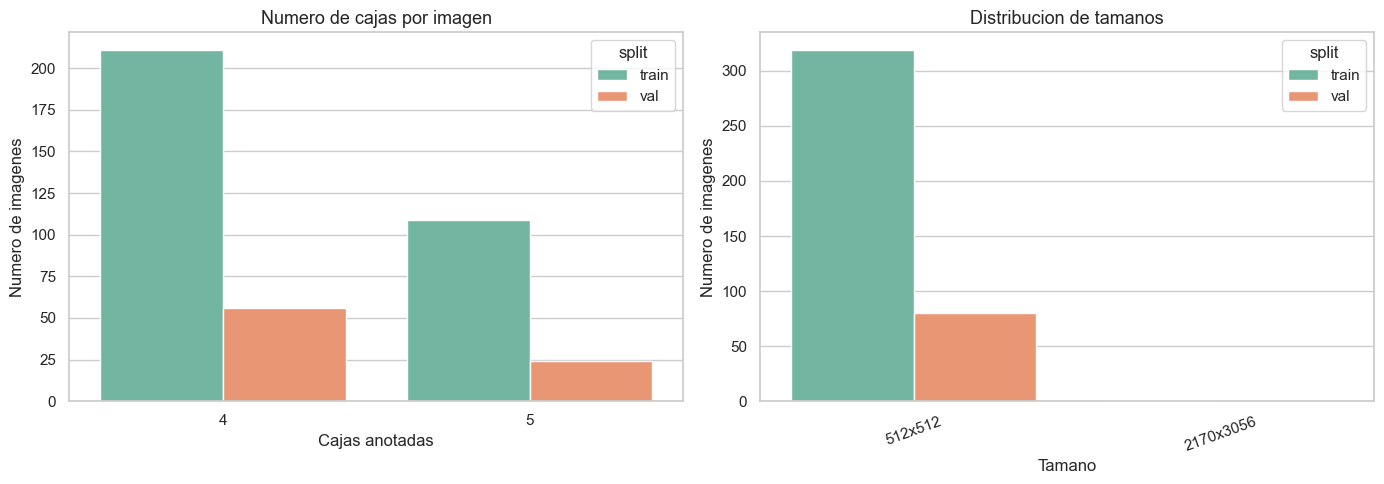

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=images_df, x="n_boxes", hue="split", ax=axes[0], palette="Set2")
axes[0].set_title("Numero de cajas por imagen")
axes[0].set_xlabel("Cajas anotadas")
axes[0].set_ylabel("Numero de imagenes")

size_labels = images_df["width"].astype(str) + "x" + images_df["height"].astype(str)
sns.countplot(x=size_labels, hue=images_df["split"], ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion de tamanos")
axes[1].set_xlabel("Tamano")
axes[1].set_ylabel("Numero de imagenes")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

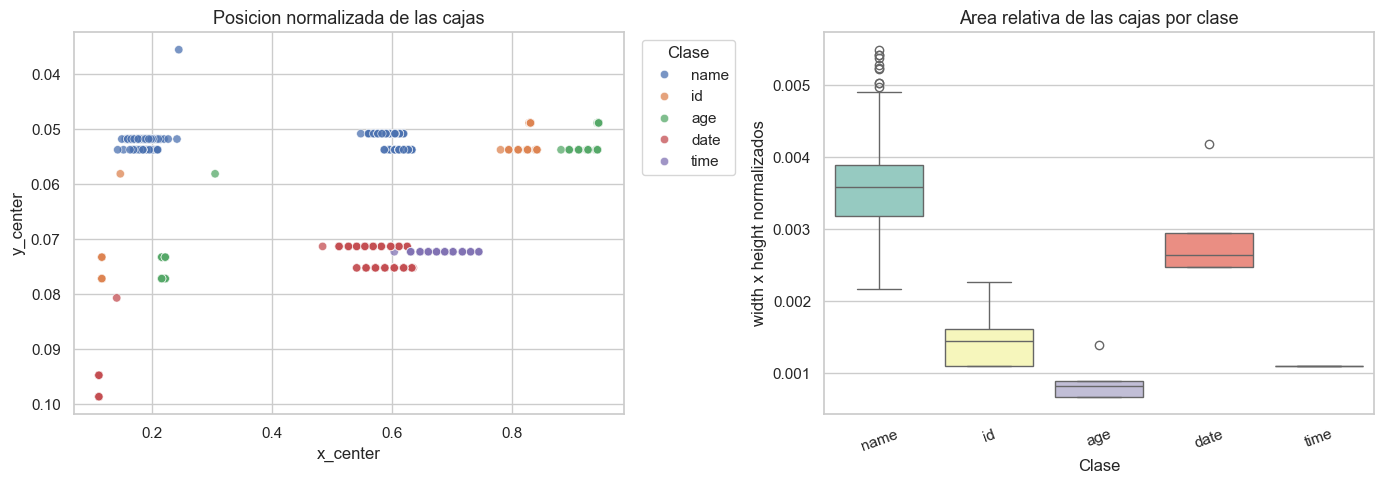

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=boxes_df,
    x="x_center",
    y="y_center",
    hue="class_name",
    hue_order=class_order,
    alpha=0.75,
    ax=axes[0],
)
axes[0].invert_yaxis()
axes[0].set_title("Posicion normalizada de las cajas")
axes[0].set_xlabel("x_center")
axes[0].set_ylabel("y_center")
axes[0].legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(data=boxes_df, x="class_name", y="area_relative", hue="class_name", order=class_order, hue_order=class_order, legend=False, ax=axes[1], palette="Set3")
axes[1].set_title("Area relativa de las cajas por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("width x height normalizados")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

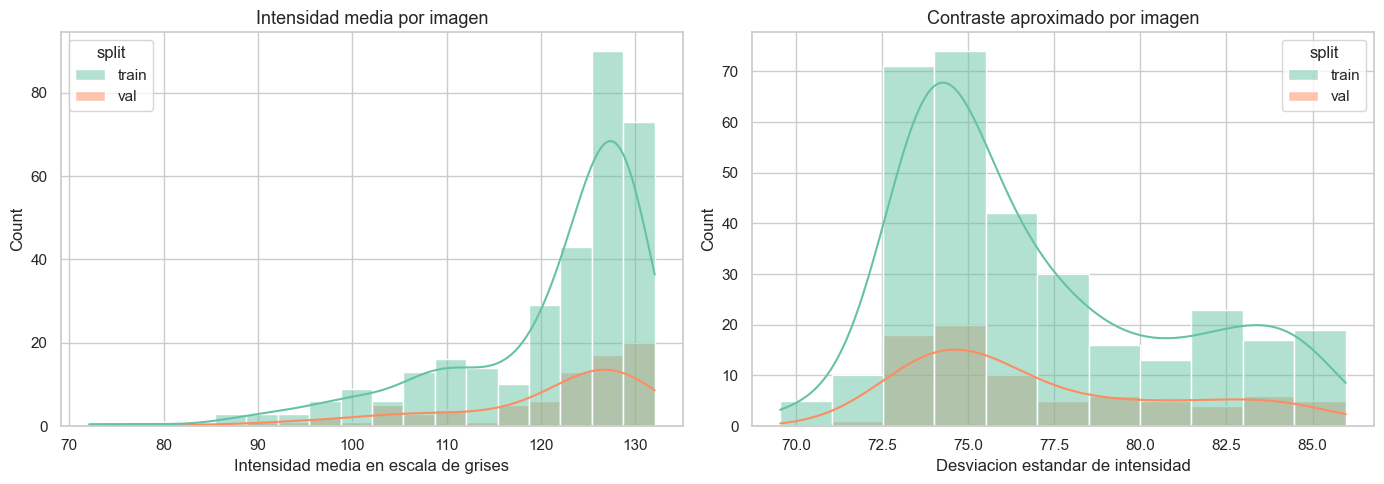

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=images_df, x="mean_intensity", hue="split", kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("Intensidad media por imagen")
axes[0].set_xlabel("Intensidad media en escala de grises")

sns.histplot(data=images_df, x="std_intensity", hue="split", kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Contraste aproximado por imagen")
axes[1].set_xlabel("Desviacion estandar de intensidad")

plt.tight_layout()
plt.show()

## 6. Conclusiones para preprocesado y augmentation

A partir de la lectura y visualizacion del dataset, estas son las decisiones recomendadas para las siguientes fases:

1. **No sobrescribir el dataset original.** La fase actual debe ser solo exploratoria. Cualquier normalizacion o augmentation debe vivir dentro del pipeline de entrenamiento.
2. **Normalizar tamanos durante el entrenamiento.** El dataset contiene 399 imagenes de 512x512 y 1 imagen de 2170x3056. Conviene redimensionar de forma controlada en el dataloader/modelo para evitar inconsistencias.
3. **Mantener las cajas en coordenadas YOLO normalizadas.** Esto facilita entrenar detectores tipo YOLO y evita recalcular etiquetas al cambiar resolucion en el pipeline.
4. **Priorizar recall sobre precision.** En desidentificacion medica, dejar texto sensible visible es mas grave que ocultar una zona ligeramente mayor.
5. **Ampliar ligeramente las cajas en la anonimimizacion final.** Para exportar imagenes anonimizadas, es recomendable expandir las cajas detectadas un 5-15% antes de cubrirlas.
6. **Usar data augmentation moderada.** Recomendable: cambios leves de brillo/contraste, ruido, compresion, pequeno escalado y traslacion. Esto puede mejorar robustez ante radiografias de diferentes equipos.
7. **Evitar augmentations agresivas.** No conviene usar rotaciones fuertes, recortes que eliminen cabeceras, blur excesivo ni transformaciones que deformen texto sensible.
8. **Vigilar la clase `time`.** Esta clase aparece menos que `name`, `id`, `age` y `date` (133 cajas frente a 400), por lo que podria necesitar especial atencion en entrenamiento y evaluacion.